# Conversation Analysis — AI Shopping Assistant

## What is implemented here

This system analyses chat conversations between customers and an AI shopping assistant deployed across **3 brands** (skincare, wellness teas, ayurvedic supplements). The goal is to surface actionable insights: where the assistant does well, where it fails, and what can be improved.

### Approach
The pipeline is intentionally layered:

1. **Data Loading** — pulls conversations + messages from MongoDB, maps each to a brand.
2. **Feature Extraction** — rolls every conversation into a single analysis row (turns, events, response length, etc.).
3. **Intent Classification (Rule-Based)** — fast keyword bucketing across 11 categories (order support, pricing, returns, skin concern, usage, etc.). Covers ~83% of conversations.
4. **Quality Scoring** — 0–3 score per conversation based on agent reply, user engagement, and cart conversion. Identifies genuine failures.
5. **LLM Hybrid Layer (Gemini Flash)** — used surgically for three tasks only: brand-specific keyword discovery, re-labelling the `other` intent bucket, and relevance auditing of ignored recommendations.
6. **Recommendation Quality** — detects whether recommendations were made, clicked, ignored (re-ask signal), and whether the agent acknowledged the user's actual concern.
7. **Conversion Funnel** — traces the journey from interaction → recommendation → click → cart across all brands.
8. **Brand-Level Insights** — breaks down every metric by brand to find where each assistant struggles specifically.

---

## Results


### Dataset
| Metric | Value |
|---|---|
| Total conversations | 300 |
| Total messages | 1,525 |
| Brands | Brand_A (skincare), Brand_B (wellness teas), Brand_C (ayurvedic supplements) |
| Avg turns per conversation | 4.2 |
| Avg agent response length | 3,832 chars |

### Intent Distribution
| Intent | Count | Notes |
|---|---|---|
| order_support | 59 | Largest single category — delivery/tracking issues |
| other | 52 | ~17% unclassified; re-labelled by Gemini in Section 5 |
| noise_or_offtopic | 38 | Greetings, thanks, single-word messages |
| offers | 34 | Discount/coupon seekers |
| skin_concern | 33 | Acne, pigmentation, dryness (Brand_A dominant) |
| usage_query | 33 | How to use / dosage / routine |
| product_discovery | 20 | Browsing / recommendation requests |
| product_info | 11 | Ingredients, benefits, suitability |
| pricing_query | 7 | Price checks |
| product_comparison | 7 | vs / which is better |
| returns | 6 | Refund/replacement requests |

### Quality & Failure
| Score | Conversations | Meaning |
|---|---|---|
| 0 | 2 | Agent didn't reply or user completely ignored — true failure |
| 1 | 223 | Agent replied, but no engagement signal |
| 2 | 75 | Agent replied + user clicked / viewed a product |
| 3 | 0 | Cart add (none occurred in this dataset) |
| **True failure rate** | **0.0%** | Scored 0 only if user sent 2+ messages — very low |

### Recommendation Signals
| Metric | Value | Interpretation |
|---|---|---|
| Recommendations made | 84.3% | Agent almost always suggests a product |
| Click-through rate (CTR) | 9.9% | Very low — most users don't engage with the product link |
| Re-ask rate (ignored rec) | 38.7% | Users kept asking after the recommendation — likely irrelevant |
| Concern acknowledged | 31.7% | Agent only echoed the user's actual concern in 1/3 of cases |

### Conversion Funnel
| Stage | Rate |
|---|---|
| Had interaction | 99.3% |
| Got recommendation | 84.3% |
| Clicked product | 24.3% |
| Added to cart | 0.0% |

### Brand Breakdown
| Brand | Quality Score | CTR | Re-ask Rate | Concern Ack | Avg Turns |
|---|---|---|---|---|---|
| Brand_A (skincare) | 1.10/3 | 2.0% | 17.0% | 35.0% | 3.3 |
| Brand_B (wellness teas) | 1.43/3 | 19.0% | 47.0% | 41.0% | 5.1 |
| Brand_C (ayurvedic) | 1.20/3 | 4.0% | 34.0% | 19.0% | 4.1 |

### Key Actionable Findings
- **Brand_B has the worst re-ask rate (47%)** — users are getting recommendations they don't engage with, then asking again. The assistant may be recommending products too broadly without understanding the user's specific health goal.
- **CTR is critically low across the board** (9.9% overall, 2% for Brand_A). The assistant makes recommendations in 84% of conversations but users click in fewer than 10%. This is the primary conversion gap.
- **Order support is the #1 intent (59 conversations)** but the assistant is an AI shopping assistant, not a logistics system. These conversations likely can't be resolved well — they should be routed to human support faster.
- **17% of conversations fall into 'other'** — the rule-based intent classifier has gaps. Gemini re-labelling (Section 5) reveals these are often very short messages (single product names, one-word queries) that need better handling.
- **Zero add-to-cart events** — no conversation in 300 resulted in a cart addition. Either the funnel is broken at the product page level, or the recommendations are so irrelevant that users never get there.
- **Concern acknowledgement is low (31.7%)** — the agent echoes the user's actual problem (e.g. "acne", "weight loss") in only 1 in 3 conversations before recommending. Better concern-mirroring language would likely improve CTR.

---


In [6]:
!pip install pymongo google-genai scikit-learn pandas numpy matplotlib seaborn -q

In [7]:
import json
import time
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pymongo import MongoClient
warnings.filterwarnings("ignore")

#this is for  local setup
# with open("messages.json") as f:
#     messages  = json.load(f)
# with open("conversations.json") as f:
#     conversations = json.load(f)

client = MongoClient("mongodb://0.tcp.in.ngrok.io:18329/")
db = client["helio_intern"]

conversations = pd.DataFrame(list(db["conversations"].find()))
messages     = pd.DataFrame(list(db["messages"].find()))

print(f"Conversations: {conversations.shape}")
print(f"Messages:      {messages.shape}")
print(f"\nConversations columns: {list(conversations.columns)}")
print(f"Messages columns:      {list(messages.columns)}")

df_msgs = pd.DataFrame(messages)
df_conv = pd.DataFrame(conversations)

BRAND_MAP = {
    "6983153e1497a62e8542a0ad": "Brand_A",   # Blue Nectar   — skincare
    "680a0a8b70a26f7a0e24eedd": "Brand_B",   # Blue Tea      — wellness teas
    "69a92ad76dcbf2da868e0f9b": "Brand_C",   # Sri Sri Tattva— ayurvedic supplements
}

df = df_msgs.merge(
    df_conv[["_id", "widgetId"]],
    left_on="conversationId", right_on="_id",
    suffixes=("", "_conv")
)
df["brand_name"] = df["widgetId"].map(BRAND_MAP)
df["timestamp"]  = pd.to_datetime(df["timestamp"])

print(f"Messages loaded  : {len(df_msgs):,}")
print(f"Conversations    : {len(df_conv):,}")
print(f"Brands           : {df['brand_name'].value_counts().to_dict()}")
print(f"Message types    : {df['messageType'].value_counts().to_dict()}")

Conversations: (300, 4)
Messages:      (1525, 7)

Conversations columns: ['_id', 'widgetId', 'createdAt', 'updatedAt']
Messages columns:      ['_id', 'conversationId', 'sender', 'text', 'messageType', 'metadata', 'timestamp']
Messages loaded  : 1,525
Conversations    : 300
Brands           : {'Brand_B': 627, 'Brand_C': 551, 'Brand_A': 347}
Message types    : {'text': 1255, 'event': 270}


## 2. Feature Extraction

In [8]:
def extract_features(conv_df):
    """
    Signals captured:
      num_turns         : total text messages (user + agent)
      clicked_link      : user fired a link_click event
      added_to_cart     : user fired add_to_cart_success event
      viewed_product    : product_view or similar_product_click event
      quick_action      : quick_action_click event
      avg_agent_resp_len: mean character length of agent replies
      all_user_text     : concatenated user messages (for intent classification)
      user_last_msg     : last thing the user said
      agent_last_msg    : last thing the agent said
    """
    conv_df   = conv_df.sort_values("timestamp").reset_index(drop=True)
    conv_id   = conv_df["conversationId"].iloc[0]
    brand     = conv_df["brand_name"].iloc[0]

    user_msgs = conv_df[(conv_df["sender"] == "user")  & (conv_df["messageType"] == "text")]
    agnt_msgs = conv_df[(conv_df["sender"] == "agent") & (conv_df["messageType"] == "text")]
    events    = conv_df[conv_df["messageType"] == "event"]["metadata"].apply(
        lambda m: m.get("eventType", "") if isinstance(m, dict) else "")

    all_user_text  = " ".join(user_msgs["text"].dropna().astype(str))
    user_last_msg  = user_msgs["text"].iloc[-1]  if len(user_msgs)  else ""
    agent_last_msg = agnt_msgs["text"].iloc[-1]  if len(agnt_msgs)  else ""
    avg_agent_len  = agnt_msgs["text"].dropna().apply(len).mean() if len(agnt_msgs) else 0

    return {
        "conversation_id":    conv_id,
        "brand_name":         brand,
        "num_turns":          len(user_msgs) + len(agnt_msgs),
        "num_user_msgs":      len(user_msgs),
        "num_agent_msgs":     len(agnt_msgs),
        "clicked_link":       "link_click"          in events.values,
        "added_to_cart":      "add_to_cart_success" in events.values,
        "viewed_product":     any(e in events.values for e in ["product_view", "similar_product_click"]),
        "quick_action":       "quick_action_click"  in events.values,
        "avg_agent_resp_len": avg_agent_len,
        "all_user_text":      all_user_text,
        "user_last_msg":      user_last_msg,
        "agent_last_msg":     agent_last_msg,
    }


df_feat = pd.DataFrame([extract_features(g) for _, g in df.groupby("conversationId")])

print(f"Feature table shape : {df_feat.shape}")
print(f"Avg turns per conv  : {df_feat['num_turns'].mean():.1f}")
print(f"Avg agent resp len  : {df_feat['avg_agent_resp_len'].mean():.0f} chars")
print("\nSample:")
print(df_feat[["brand_name","num_turns","clicked_link","added_to_cart"]].head(5).to_string(index=False))

Feature table shape : (300, 13)
Avg turns per conv  : 4.2
Avg agent resp len  : 3832 chars

Sample:
brand_name  num_turns  clicked_link  added_to_cart
   Brand_A          2         False          False
   Brand_A          2         False          False
   Brand_A          2          True          False
   Brand_A          2         False          False
   Brand_A          4         False          False


## 3.Rule-Based Intent Classification

In [9]:
def detect_intent(text):
    """
    Keyword-based intent classifier across 11 categories.
    Order matters — more specific checks (offers, returns) come
    before broader ones (order_support, pricing_query).
    The 'other' bucket is fed into the LLM layer in Section 5
    to surface gaps in these rules.
    """
    text = str(text).lower()

    if any(w in text for w in ["discount","offer","coupon","sale","deal","promo","free","cashback"]):
        return "offers"
    if any(w in text for w in ["price","cost","₹","rs ","how much","rate","mrp","charges"]):
        return "pricing_query"
    if any(w in text for w in ["return","refund","replace","exchange","damage","wrong item","missing"]):
        return "returns"
    if any(w in text for w in ["order","track","delivery","shipped","dispatch","status","when will",
                                "arrive","package","received","not delivered","pending","cancel"]):
        return "order_support"
    if any(w in text for w in ["acne","pimple","oily skin","dry skin","pigment","dark spot","glowing",
                                "sensitive skin","tan","wrinkle","dark circle","rash","itch","irritat",
                                "blemish","scar","brightening","tone","complexion","ageing","aging"]):
        return "skin_concern"
    if any(w in text for w in ["compare","vs","versus","better","difference between","which one","alternative"]):
        return "product_comparison"
    if any(w in text for w in ["how to use","how do i use","apply","usage","when to apply","routine",
                                "steps","direction","dosage","how many","how often","daily"]):
        return "usage_query"
    if any(w in text for w in ["ingredient","contain","made of","formula","composition","what is in",
                                "key ingredient","benefit","effect","work","suitable","good for"]):
        return "product_info"
    if any(w in text for w in ["recommend","suggest","looking for","need","want","find","best",
                                "which product","which one should","help me","what should i","for my"]):
        return "product_discovery"
    if any(w in text for w in ["hi","hello","hey","hii","hlo","good morning","good evening",
                                "thanks","thank you","ok","okay","bye","great","nice","cool","noted"]):
        return "noise_or_offtopic"
    return "other"


df_feat["intent"] = df_feat["all_user_text"].apply(detect_intent)

print("Intent distribution:")
print(df_feat["intent"].value_counts().to_string())
print(f"\n'other' rate: {(df_feat['intent']=='other').mean():.1%} ")

Intent distribution:
intent
order_support         59
other                 52
noise_or_offtopic     38
offers                34
skin_concern          33
usage_query           33
product_discovery     20
product_info          11
pricing_query          7
product_comparison     7
returns                6

'other' rate: 17.3% 


## 4. Failure Detection & Conversation Quality Score

In [10]:
def score_conversation(row):
    """
    0–3 quality score (replaces blunt pass/fail flag).

    Score logic:
      +1 : agent replied at all
      +1 : user showed engagement (clicked link, viewed product)
      +1 : user added to cart (strongest positive signal)

    failure = True only when score == 0 AND user sent more than 1 message
    (so single-message drop-offs don't pollute the failure rate)
    """
    score = 0
    if row["num_agent_msgs"] > 0:                                             score += 1
    if row["clicked_link"] or row["viewed_product"] or row["added_to_cart"]:  score += 1
    if row["added_to_cart"]:                                                   score += 1
    failure = (score == 0) and (row["num_user_msgs"] > 1)
    return pd.Series({"quality_score": score, "failure": failure})


df_feat[["quality_score", "failure"]] = df_feat.apply(score_conversation, axis=1)

print("Quality score distribution:")
print(df_feat["quality_score"].value_counts().sort_index().to_string())
print(f"\nAvg quality score : {df_feat['quality_score'].mean():.2f} / 3")
print(f"True failure rate : {df_feat['failure'].mean():.1%}")

Quality score distribution:
quality_score
0      2
1    223
2     75

Avg quality score : 1.24 / 3
True failure rate : 0.0%


## 5. LLM Hybrid Layer — Brand Keyword Discovery & Validation

This would help us identify the keywords specific to brand and it can be sued to score the responses


In [ ]:
# GEMINI SETUP
from google import genai

GEMINI_API_KEY = ""
gemini_client  = genai.Client(api_key=GEMINI_API_KEY)


def call_gemini_with_retry(prompt, max_retries=5):
    """Exponential backoff for Gemini free-tier rate limits (429)."""
    for attempt in range(max_retries):
        try:
            resp = gemini_client.models.generate_content(
                model="gemini-2.0-flash",
                contents=prompt
            )
            return resp.text.strip()
        except Exception as e:
            err = str(e)
            if "429" in err or "RESOURCE_EXHAUSTED" in err:
                wait = 10 * (2 ** attempt)
                print(f"  Rate limited — waiting {wait}s (attempt {attempt+1}/{max_retries})…")
                time.sleep(wait)
            else:
                raise
    raise Exception(f"Gemini: max retries exceeded after {max_retries} attempts")

In [ ]:
KEYWORD_PROMPT = """You are analysing customer chat conversations with an AI shopping assistant.

Below are {n} customer messages from a single brand's users.

Your tasks:
1. Infer what type of products this brand sells (one short phrase).
2. List the specific user concerns, problems, or needs that appear.
   Focus on domain-specific words a rule-based system should match.

Return ONLY valid JSON — no markdown, no explanation:
{{
  "brand_category": "...",
  "concern_keywords": ["keyword1", "keyword2", ...]
}}

Customer messages:
{messages}"""

brand_keywords = {}

for brand in df_feat["brand_name"].unique():
    print(f"\nDiscovering keywords for: {brand}")
    sample = df_feat[df_feat["brand_name"]==brand].sample(min(15, (df_feat["brand_name"]==brand).sum()), random_state=42)
    msg_block = "\n---\n".join(str(row["all_user_text"])[:200] for _, row in sample.iterrows())
    prompt    = KEYWORD_PROMPT.format(n=len(sample), messages=msg_block)
    try:
        raw     = call_gemini_with_retry(prompt)
        clean   = raw.replace("```json","").replace("```","").strip()
        parsed  = json.loads(clean)
        category = parsed.get("brand_category","unknown")
        keywords = [k.lower().strip() for k in parsed.get("concern_keywords",[])]
        brand_keywords[brand] = keywords
        print(f"  Category : {category}")
        print(f"  Keywords : {keywords}")
    except Exception as e:
        print(f"  ERROR: {e}")
        brand_keywords[brand] = []
    time.sleep(8)

print("\n✓ Brand keyword discovery complete.")
print("\nbrand_keywords summary:")
for b, kws in brand_keywords.items():
    print(f"  {b}: {kws}")

In [ ]:
other_sample = (
    df_feat[df_feat["intent"] == "other"]
    .sample(min(10, (df_feat["intent"]=="other").sum()), random_state=42)
)

INTENT_PROMPT = """You are analysing customer messages to an AI shopping assistant.

Classify this customer message into exactly ONE of these intents:
pricing_query | product_discovery | order_support | returns | offers |
skin_concern | product_comparison | usage_query | product_info |
noise_or_offtopic | other

Customer message: \"{msg}\"

Reply with ONLY the intent label, nothing else."""

llm_intents = []

for _, row in other_sample.iterrows():
    try:
        msg   = str(row["all_user_text"])[:300]
        label = call_gemini_with_retry(INTENT_PROMPT.format(msg=msg)).lower().replace(" ","_")
        llm_intents.append({"conversation_id":row["conversation_id"],"brand_name":row["brand_name"],
                             "user_text":msg,"rule_intent":"other","llm_intent":label})
    except Exception as e:
        llm_intents.append({"conversation_id":row["conversation_id"],"brand_name":row["brand_name"],
                             "user_text":str(row["all_user_text"])[:300],"rule_intent":"other",
                             "llm_intent":f"error: {str(e)[:50]}"})
    time.sleep(5)

df_llm_intent = pd.DataFrame(llm_intents)
print("LLM intent re-labels for 'other' bucket:")
print(df_llm_intent["llm_intent"].value_counts())
print("\nSample:")
print(df_llm_intent[["brand_name","user_text","llm_intent"]].head(5).to_string(index=False))

## 6. Product Recommendation Quality

In [ ]:
if "brand_keywords" not in dir() or not brand_keywords:
    brand_keywords = {
        "Brand_A": ["acne","pimple","oily","dry skin","pigment","dark spot","sensitive",
                    "tan","glow","wrinkle","dark circle","blemish","scar","brightening"],
        "Brand_B": ["weight","fat","diabetic","sugar","sleep","stress","energy","immunity",
                    "digestion","detox","cholesterol","blood pressure","metabolism"],
        "Brand_C": ["ayurvedic","herb","vata","pitta","kapha","immunity","digestion",
                    "joint","pain","ghee","granules","tablet","powder","churna","ashwagandha"],
    }


def analyze_recommendation_quality(conv_df, brand_keywords):
    """
    Per-conversation recommendation analysis.

    Signals:
      recommendation_made    : agent reply contained a product link
      recommendation_clicked : product_view event within 3 turns after rec
      user_re_asked          : user sent another query after recommendation
                               (likely ignored it → irrelevant recommendation)
      concern_acknowledged   : agent echoed the user's concern keyword
                               Uses brand_keywords — valid for ALL brands,
                               not just skincare.
    """
    conv_df = conv_df.sort_values("timestamp").reset_index(drop=True)
    conv_id = conv_df["conversationId"].iloc[0]
    brand   = conv_df["brand_name"].iloc[0]
    concern_words = brand_keywords.get(brand, [])

    rec_made = rec_clicked = user_re_asked = concern_ack = False

    for i, row in conv_df.iterrows():
        if row["sender"] == "agent" and row["messageType"] == "text":
            text = str(row["text"])

            if "http" in text or "**[" in text or "[**" in text:
                rec_made = True
                window   = conv_df.iloc[i+1 : i+4]

                for _, w in window.iterrows():
                    if w["messageType"] == "event":
                        meta = w["metadata"]
                        if isinstance(meta, dict) and meta.get("eventType") == "product_view":
                            rec_clicked = True
                    if w["sender"] == "user" and w["messageType"] == "text":
                        user_re_asked = True

                if concern_words:
                    prev = conv_df.iloc[:i][conv_df.iloc[:i]["sender"] == "user"]
                    if not prev.empty:
                        ut = str(prev.iloc[-1]["text"]).lower()
                        if any(c in ut for c in concern_words) and any(c in text.lower() for c in concern_words):
                            concern_ack = True

    return {"conversation_id":conv_id,"recommendation_made":rec_made,
            "recommendation_clicked":rec_clicked,"user_re_asked":user_re_asked,
            "concern_acknowledged":concern_ack}


rec_data = [analyze_recommendation_quality(g, brand_keywords) for _, g in df.groupby("conversationId")]
df_rec   = pd.DataFrame(rec_data)

for col in ["recommendation_made","recommendation_clicked","user_re_asked","concern_acknowledged"]:
    if col in df_feat.columns: df_feat.drop(columns=[col], inplace=True)
df_feat = df_feat.merge(df_rec, on="conversation_id")

rec_df = df_feat[df_feat["recommendation_made"]]
print("Recommendation signal summary:")
print(f"  Conversations with recommendation made   : {df_feat['recommendation_made'].sum()} ({df_feat['recommendation_made'].mean():.1%})")
print(f"  Of those — recommendation clicked (CTR)  : {rec_df['recommendation_clicked'].sum()} ({rec_df['recommendation_clicked'].mean():.1%})")
print(f"  Of those — user re-asked (ignored rec)   : {rec_df['user_re_asked'].sum()} ({rec_df['user_re_asked'].mean():.1%})")
print(f"  Concern acknowledged by agent            : {df_feat['concern_acknowledged'].sum()} ({df_feat['concern_acknowledged'].mean():.1%})")
print(f"\n  Overall CTR              : {rec_df['recommendation_clicked'].mean():.1%}")
print(f"  Re-ask rate              : {rec_df['user_re_asked'].mean():.1%}")

In [ ]:
re_ask_pool = df_feat[(df_feat["user_re_asked"]==True) & (df_feat["recommendation_made"]==True)]
re_ask_sample = re_ask_pool.sample(min(10, len(re_ask_pool)), random_state=42)

RELEVANCE_PROMPT = """You are evaluating an AI shopping assistant.

Customer asked : \"{user_msg}\"
Assistant replied: \"{agent_msg}\"

Was the assistant's response relevant and helpful?
Reply in this exact format:
verdict: YES or NO
reason: one sentence explanation"""

relevance_results = []

for _, row in re_ask_sample.iterrows():
    try:
        prompt  = RELEVANCE_PROMPT.format(user_msg=str(row["user_last_msg"])[:200],
                                          agent_msg=str(row["agent_last_msg"])[:400])
        output  = call_gemini_with_retry(prompt)
        verdict = "YES" if "verdict: yes" in output.lower() else "NO"
        reason  = output.split("reason:")[-1].strip() if "reason:" in output.lower() else output
        relevance_results.append({"conversation_id":row["conversation_id"],"brand_name":row["brand_name"],
                                   "user_msg":str(row["user_last_msg"])[:100],
                                   "agent_msg":str(row["agent_last_msg"])[:100],
                                   "llm_verdict":verdict,"llm_reason":reason})
    except Exception as e:
        relevance_results.append({"conversation_id":row["conversation_id"],"brand_name":row["brand_name"],
                                   "user_msg":str(row["user_last_msg"])[:100],
                                   "agent_msg":str(row["agent_last_msg"])[:100],
                                   "llm_verdict":"error","llm_reason":str(e)[:100]})
    time.sleep(5)

df_relevance = pd.DataFrame(relevance_results)
print("=== Recommendation Relevance Audit ===")
print(df_relevance["llm_verdict"].value_counts())
irr = (df_relevance["llm_verdict"]=="NO").mean()
print(f"\nIrrelevant recommendation rate: {irr:.1%}")
no_df = df_relevance[df_relevance["llm_verdict"]=="NO"]
if len(no_df): print(no_df[["brand_name","user_msg","llm_reason"]].to_string(index=False))

## 7. Additional Signals: Response Length & Events

In [13]:
resp_stats = (
    df_feat[df_feat["avg_agent_resp_len"] > 0]
    .groupby("brand_name")["avg_agent_resp_len"]
    .describe()[["mean","50%","min","max"]]
    .rename(columns={"50%":"median"})
    .round(0)
)
print("Agent response length (characters):")
print(resp_stats.to_string())

#Event type breakdown
event_counts = (
    df[df["messageType"] == "event"]["metadata"]
    .apply(lambda m: m.get("eventType","unknown") if isinstance(m,dict) else "unknown")
    .value_counts()
)
print("\nEvent type distribution:")
print(event_counts.to_string())

Agent response length (characters):
              mean  median    min      max
brand_name                                
Brand_A     5335.0  5909.0   67.0  11741.0
Brand_B     2603.0  2624.0  126.0   6858.0
Brand_C     3610.0  3568.0  115.0  11798.0

Event type distribution:
metadata
link_click               179
quick_action_click        52
product_view              33
similar_product_click      4
menu_action_click          2


## 8. Conversion Funnel Analysis

In [14]:
def build_funnel(conv_df):
    conv_df = conv_df.sort_values("timestamp").reset_index(drop=True)
    events  = conv_df[conv_df["messageType"]=="event"]["metadata"].apply(
        lambda m: m.get("eventType","") if isinstance(m,dict) else "")
    return pd.Series({
        "had_interaction":    len(conv_df) > 1,
        "got_recommendation": any("http" in str(t) or "**[" in str(t)
                                  for t in conv_df[conv_df["sender"]=="agent"]["text"].dropna()),
        "clicked_product":    "link_click" in events.values or "product_view" in events.values,
        "added_to_cart":      "add_to_cart_success" in events.values,
    })


funnel_df      = df.groupby("conversationId").apply(build_funnel, include_groups=False).reset_index()
funnel_summary = funnel_df[["had_interaction","got_recommendation","clicked_product","added_to_cart"]].mean()

funnel_df2 = funnel_df.merge(df_conv[["_id","widgetId"]], left_on="conversationId", right_on="_id")
funnel_df2["brand_name"] = funnel_df2["widgetId"].map(BRAND_MAP)

def brand_funnel_agg(g):
    return pd.Series({k: g[k].mean() for k in
                      ["had_interaction","got_recommendation","clicked_product","added_to_cart"]})

brand_funnel = funnel_df2.groupby("brand_name").apply(brand_funnel_agg, include_groups=False).reset_index()

print("Overall conversion funnel:")
for step, val in funnel_summary.items():
    print(f"  {step:<25} {val:.1%}")

print("\nFunnel by brand:")
print(brand_funnel.set_index("brand_name").round(3).to_string())

Overall conversion funnel:
  had_interaction           99.3%
  got_recommendation        84.3%
  clicked_product           24.3%
  added_to_cart             0.0%

Funnel by brand:
            had_interaction  got_recommendation  clicked_product  added_to_cart
brand_name                                                                     
Brand_A                1.00                0.83             0.10            0.0
Brand_B                0.98                0.83             0.44            0.0
Brand_C                1.00                0.87             0.19            0.0


## 9. Brand-Level Insights

In [ ]:
brand_summary = df_feat.groupby("brand_name").agg(
    avg_quality_score = ("quality_score",         "mean"),
    failure_rate      = ("failure",               "mean"),
    avg_turns         = ("num_turns",             "mean"),
    rec_made_rate     = ("recommendation_made",   "mean"),
    ctr               = ("recommendation_clicked","mean"),
    re_ask_rate       = ("user_re_asked",         "mean"),
    concern_ack_rate  = ("concern_acknowledged",  "mean"),
)

print("Brand-level summary:")
print(brand_summary.round(3).to_string())

print("\nIntent breakdown by brand:")
brand_intent_pivot = df_feat.groupby(["brand_name","intent"]).size().unstack(fill_value=0)
print(brand_intent_pivot.to_string())

## 10. Visualizations

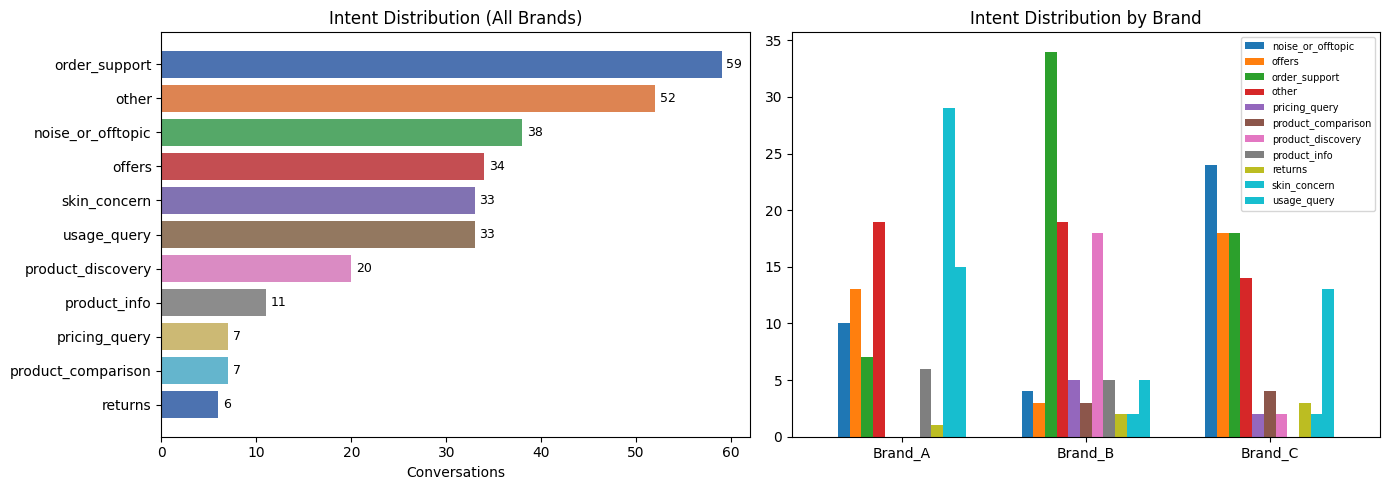

In [16]:
COLORS  = {"Brand_A":"#4C72B0","Brand_B":"#DD8452","Brand_C":"#55A868"}
PALETTE = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860","#DA8BC3","#8C8C8C","#CCB974","#64B5CD","#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

intent_counts = df_feat["intent"].value_counts()
axes[0].barh(intent_counts.index, intent_counts.values, color=PALETTE[:len(intent_counts)])
axes[0].set_xlabel("Conversations"); axes[0].set_title("Intent Distribution (All Brands)")
axes[0].invert_yaxis()
for i, v in enumerate(intent_counts.values):
    axes[0].text(v+0.5, i, str(v), va="center", fontsize=9)

brand_intent_pivot = df_feat.groupby(["brand_name","intent"]).size().unstack(fill_value=0)
brand_intent_pivot.plot(kind="bar", ax=axes[1], colormap="tab10", width=0.7)
axes[1].set_title("Intent Distribution by Brand"); axes[1].set_xlabel("")
axes[1].legend(loc="upper right", fontsize=7); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qs   = df_feat["quality_score"].value_counts().sort_index()
bars = axes[0].bar(["Score 0","Score 1","Score 2","Score 3"][:len(qs)], qs.values,
                   color=["#C44E52","#DD8452","#4C72B0","#55A868"][:len(qs)])
axes[0].set_title("Conversation Quality Score Distribution"); axes[0].set_ylabel("Conversations")
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(int(bar.get_height())), ha="center", fontsize=10)

rec_df  = df_feat[df_feat["recommendation_made"]]
metrics = {
    "Rec Made\n(all)":          df_feat["recommendation_made"].mean(),
    "CTR\n(of rec made)":       rec_df["recommendation_clicked"].mean(),
    "Re-asked\n(of rec made)":  rec_df["user_re_asked"].mean(),
    "Concern Ack\n(all)":       df_feat["concern_acknowledged"].mean(),
}
axes[1].bar(metrics.keys(), metrics.values(), color=["#4C72B0","#55A868","#C44E52","#DD8452"])
axes[1].set_title("Recommendation Quality Signals"); axes[1].set_ylabel("Rate"); axes[1].set_ylim(0, 1.05)
for i, (k,v) in enumerate(metrics.items()):
    axes[1].text(i, v+0.02, f"{v:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

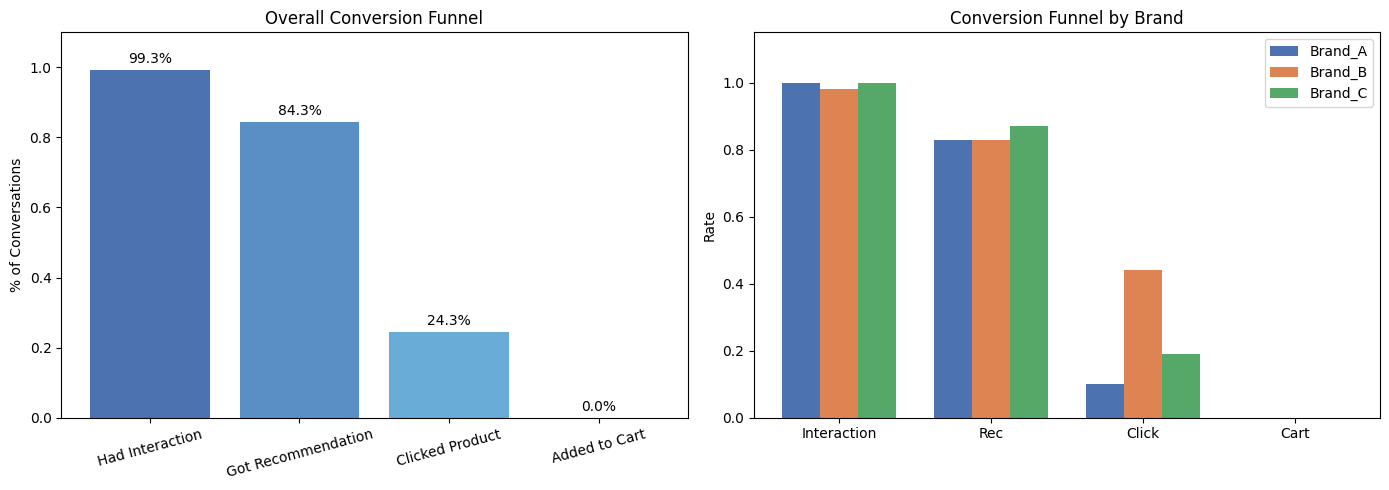

In [18]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

steps = ["Had Interaction","Got Recommendation","Clicked Product","Added to Cart"]
vals  = [funnel_summary["had_interaction"], funnel_summary["got_recommendation"],
         funnel_summary["clicked_product"],  funnel_summary["added_to_cart"]]
bars2 = axes[0].bar(steps, vals, color=["#4C72B0","#5A8FC5","#6AACD8","#7BC9EB"])
axes[0].set_title("Overall Conversion Funnel"); axes[0].set_ylabel("% of Conversations"); axes[0].set_ylim(0, 1.1)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f"{bar.get_height():.1%}", ha="center", fontsize=10)
axes[0].tick_params(axis="x", rotation=15)

x, width = np.arange(len(steps)), 0.25
for idx, (brand, color) in enumerate(COLORS.items()):
    row   = brand_funnel[brand_funnel["brand_name"]==brand].iloc[0]
    bvals = [row["had_interaction"],row["got_recommendation"],row["clicked_product"],row["added_to_cart"]]
    axes[1].bar(x+idx*width, bvals, width, label=brand, color=color)
axes[1].set_xticks(x+width); axes[1].set_xticklabels(["Interaction","Rec","Click","Cart"])
axes[1].set_title("Conversion Funnel by Brand"); axes[1].set_ylabel("Rate"); axes[1].legend(); axes[1].set_ylim(0,1.15)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brands = brand_summary.index.tolist()
x2, w2 = np.arange(len(brands)), 0.22
metric_groups = {
    "Avg Quality (÷3)": brand_summary["avg_quality_score"]/3,
    "CTR":              brand_summary["ctr"],
    "Re-ask Rate":      brand_summary["re_ask_rate"],
    "Concern Ack":      brand_summary["concern_ack_rate"],
}
for i, (label, vals2) in enumerate(metric_groups.items()):
    axes[0].bar(x2+i*w2, vals2.values, w2, label=label, color=["#4C72B0","#55A868","#C44E52","#DD8452"][i])
axes[0].set_xticks(x2+w2*1.5); axes[0].set_xticklabels(brands)

intent_fail = (df_feat[df_feat["intent"]!="noise_or_offtopic"]
               .groupby("intent")["failure"].mean().sort_values(ascending=False))
axes[1].barh(intent_fail.index, intent_fail.values, color=PALETTE[:len(intent_fail)])
plt.tight_layout()
plt.show()

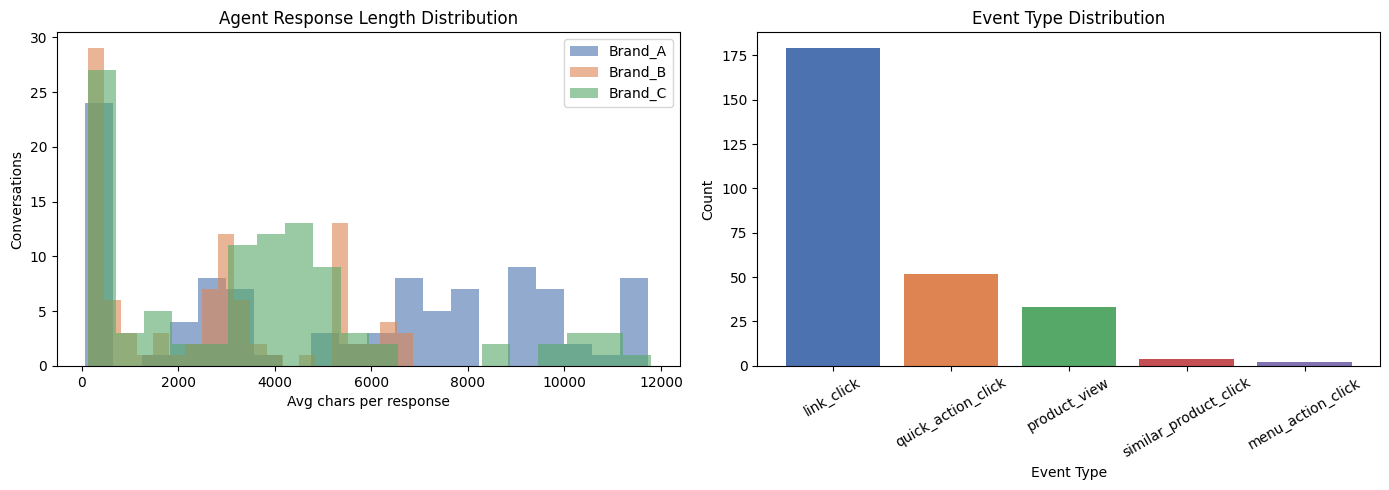

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for brand, color in COLORS.items():
    subset = df_feat[(df_feat["brand_name"]==brand) & (df_feat["avg_agent_resp_len"]>0)]["avg_agent_resp_len"]
    axes[0].hist(subset, bins=20, alpha=0.6, label=brand, color=color)
axes[0].set_title("Agent Response Length Distribution"); axes[0].set_xlabel("Avg chars per response")
axes[0].set_ylabel("Conversations"); axes[0].legend()

event_counts = (df[df["messageType"]=="event"]["metadata"]
                .apply(lambda m: m.get("eventType","unknown") if isinstance(m,dict) else "unknown")
                .value_counts())
axes[1].bar(event_counts.index, event_counts.values, color=PALETTE[:len(event_counts)])
axes[1].set_title("Event Type Distribution"); axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Count"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 11. Summary of Insights

In [21]:
print("""============================================================
ACTIONABLE INSIGHTS SUMMARY
============================================================

[1] OVERALL HEALTH
    Total conversations:      300
    Avg turns per conv:       4.18
    Avg quality score:        1.2433/3
    True failure rate:        0.0%

[2] INTENT COVERAGE
  order_support             59
  other                     52
  noise_or_offtopic         38
  offers                    34
  skin_concern              33
  usage_query               33
  product_discovery         20
  product_info              11
  pricing_query             7
  product_comparison        7
  returns                   6

[3] QUALITY SCORE DISTRIBUTION
  Score 0: 2 conversations
  Score 1: 223 conversations
  Score 2: 75 conversations

[4] RECOMMENDATION SIGNALS
    Recommendations made:     253 (84.3%)
    Click-through rate (CTR): 9.9%
    Re-ask rate (ignored):    38.7%
    Concern acknowledged:     95 (31.7%)

[5] CONVERSION FUNNEL
  had_interaction           99.3%
  got_recommendation        84.3%
  clicked_product           24.3%
  added_to_cart             0.0%

[6] BRAND BREAKDOWN
  Brand_A:
    Avg quality score : 1.10/3
    CTR               : 2.0%
    Re-ask rate       : 17.0%
    Concern ack rate  : 35.0%
    Avg turns         : 3.3

  Brand_B:
    Avg quality score : 1.43/3
    CTR               : 19.0%
    Re-ask rate       : 47.0%
    Concern ack rate  : 41.0%
    Avg turns         : 5.1

  Brand_C:
    Avg quality score : 1.20/3
    CTR               : 4.0%
    Re-ask rate       : 34.0%
    Concern ack rate  : 19.0%
    Avg turns         : 4.1
============================================================""")

ACTIONABLE INSIGHTS SUMMARY

[1] OVERALL HEALTH
    Total conversations:      300
    Avg turns per conv:       4.18
    Avg quality score:        1.2433/3
    True failure rate:        0.0%

[2] INTENT COVERAGE
  order_support             59
  other                     52
  noise_or_offtopic         38
  offers                    34
  skin_concern              33
  usage_query               33
  product_discovery         20
  product_info              11
  pricing_query             7
  product_comparison        7
  returns                   6

[3] QUALITY SCORE DISTRIBUTION
  Score 0: 2 conversations
  Score 1: 223 conversations
  Score 2: 75 conversations

[4] RECOMMENDATION SIGNALS
    Recommendations made:     253 (84.3%)
    Click-through rate (CTR): 9.9%
    Re-ask rate (ignored):    38.7%
    Concern acknowledged:     95 (31.7%)

[5] CONVERSION FUNNEL
  had_interaction           99.3%
  got_recommendation        84.3%
  clicked_product           24.3%
  added_to_cart            